In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/test.csv.zip
/kaggle/input/train.csv.zip
/kaggle/input/description.md
/kaggle/input/sample_submission.csv
/kaggle/input/train.csv
/kaggle/input/test.csv
/kaggle/input/sample_submission.csv.zip
/kaggle/input/tabular-playground-series-may-2022/test.csv.zip
/kaggle/input/tabular-playground-series-may-2022/train.csv.zip
/kaggle/input/tabular-playground-series-may-2022/description.md
/kaggle/input/tabular-playground-series-may-2022/sample_submission.csv
/kaggle/input/tabular-playground-series-may-2022/train.csv
/kaggle/input/tabular-playground-series-may-2022/test.csv
/kaggle/input/tabular-playground-series-may-2022/sample_submission.csv.zip


In [3]:
train = pd.read_csv("/kaggle/input/tabular-playground-series-may-2022/train.csv")
test = pd.read_csv("/kaggle/input/tabular-playground-series-may-2022/test.csv")
submission = pd.read_csv(
    "/kaggle/input/tabular-playground-series-may-2022/sample_submission.csv"
)



In [4]:
train



,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,...,f_22,f_23,f_24,f_25,f_26,f_27,f_28,f_29,f_30,target
0,0,-0.249088,0.530642,0.335227,0.806819,-0.184190,-0.560442,1.253767,2,1,...,-1.100706,-0.078688,2.160728,0.002502,-0.827445,ACBADABECB,158.820720,0,1,1
1,1,-0.312833,0.033082,-0.571193,1.311494,0.991718,-0.138249,1.834627,2,1,...,1.089416,-2.701227,-1.846792,9.539707,2.443596,BBBCAAAFDE,211.389880,0,0,0
2,2,-0.370032,1.501016,0.288983,0.077866,-0.329701,0.030314,0.384582,1,3,...,0.313065,0.293554,-3.490299,2.002782,0.593525,BDAEAABICD,81.745258,1,0,0
3,3,-1.011059,-0.341850,1.415175,-2.128660,1.137287,-3.200017,0.289945,7,2,...,-0.626560,0.989921,-0.760995,-3.276785,-2.534943,BAABFADDCA,-644.638548,0,0,1
4,4,0.756528,0.503700,0.935057,-2.321849,-0.002466,0.058981,-0.163493,1,0,...,-1.504338,0.632537,1.812423,2.883524,-1.089711,AABFBBEMHC,-140.205455,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799995,799995,-1.775014,-0.317612,-1.701617,0.598382,-0.199084,-0.433328,-0.767980,1,1,...,1.721531,-0.156203,-3.178128,1.083564,-3.163578,ACBCBBDAAB,-104.533515,1,0,0
799996,799996,-0.767127,-0.542611,-0.302674,2.344318,-0.354326,-0.377939,0.426515,1,4,...,-0.843689,2.072953,-5.796239,1.512522,-2.797038,BDBBBBDSEA,107.715914,1,2,0
799997,799997,-2.365336,0.145508,-0.271220,2.032548,-0.255044,-2.290814,0.986708,3,1,...,-3.333447,-2.532973,-2.647231,2.383709,2.821434,BBBECADQCC,-87.804532,0,0,0
799998,799998,-0.457002,-0.807948,0.517267,-0.375132,1.831179,0.558692,-0.985251,0,0,...,-4.125115,-0.266739,1.546630,-3.668759,2.827343,AGBBAABBDE,-80.569055,0,0,0


In [5]:
test



,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,...,f_21,f_22,f_23,f_24,f_25,f_26,f_27,f_28,f_29,f_30
0,800000,0.194491,1.180926,-1.474570,-1.969979,-0.632224,-0.908537,-0.929414,3,0,...,5.540808,0.566451,-3.640977,-3.134273,4.232714,1.411271,BBAABACIFB,-380.668584,0,1
1,800001,0.073512,1.215182,1.887183,0.664100,1.445916,0.407144,-0.965463,1,0,...,-0.562313,1.033356,3.351333,-1.598481,-1.585360,-0.413281,AABBBBDHCC,602.721455,0,0
2,800002,0.990606,1.390944,0.765208,-0.204159,-0.265682,0.051791,2.526925,6,4,...,1.094242,-3.755136,1.450646,7.071502,1.467113,2.519946,BEBBBAALCB,451.547357,0,0
3,800003,0.621236,-1.282787,0.836890,1.208417,-0.212496,-1.729244,-0.741488,3,1,...,0.222260,5.028227,-1.303147,-3.905412,2.162827,-1.369400,ADBBBBDNCE,-193.028625,1,1
4,800004,-0.143469,0.952492,-0.146993,0.362883,-0.105120,-1.208656,-1.317498,2,1,...,-5.391257,-0.667532,-0.731155,3.807904,-1.748775,1.013688,ABACAAFACE,50.602827,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,899995,0.503418,-1.153300,-0.889425,-1.179513,-0.462061,0.214669,0.307743,1,3,...,-0.014319,-1.165309,-0.846506,-2.378787,1.427360,2.826281,BCBCBBBLKC,76.703552,0,0
99996,899996,-0.902133,-0.627760,0.162088,-1.615119,0.879754,0.987410,0.825034,0,2,...,0.724684,0.317879,-1.793405,-0.431504,-5.388516,0.566487,ABABAADDEB,-157.343660,1,0
99997,899997,-1.832058,1.262797,-0.624058,-0.527734,0.197212,-0.253486,1.778342,1,2,...,-5.757202,-1.618524,-3.945195,1.268688,-2.000294,-3.963489,AFADGADFBB,38.082804,0,0
99998,899998,0.046550,-1.341361,-0.785497,-0.997895,-0.603070,-0.325951,0.479813,4,2,...,1.010819,-2.338393,-0.620072,2.750694,-1.080191,5.363695,AEBBAABGBB,-366.456080,0,0


In [6]:
submission



,id,target
0,800000,0.5
1,800001,0.5
2,800002,0.5
3,800003,0.5
4,800004,0.5
...,...,...
99995,899995,0.5
99996,899996,0.5
99997,899997,0.5
99998,899998,0.5


In [7]:
train.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 33 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      800000 non-null  int64  
 1   f_00    800000 non-null  float64
 2   f_01    800000 non-null  float64
 3   f_02    800000 non-null  float64
 4   f_03    800000 non-null  float64
 5   f_04    800000 non-null  float64
 6   f_05    800000 non-null  float64
 7   f_06    800000 non-null  float64
 8   f_07    800000 non-null  int64  
 9   f_08    800000 non-null  int64  
 10  f_09    800000 non-null  int64  
 11  f_10    800000 non-null  int64  
 12  f_11    800000 non-null  int64  
 13  f_12    800000 non-null  int64  
 14  f_13    800000 non-null  int64  
 15  f_14    800000 non-null  int64  
 16  f_15    800000 non-null  int64  
 17  f_16    800000 non-null  int64  
 18  f_17    800000 non-null  int64  
 19  f_18    800000 non-null  int64  
 20  f_19    800000 non-null  float64
 21  f_20    80

In [8]:
train.describe()



,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,...,f_21,f_22,f_23,f_24,f_25,f_26,f_28,f_29,f_30,target
count,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,...,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000
mean,399999.500000,-0.000459,0.001238,0.001304,-0.001661,-0.000565,0.001002,-0.000375,2.032190,2.058831,...,-0.157764,-0.008572,-0.369088,-0.343851,0.177661,0.357211,-0.342971,0.345513,1.002873,0.486140
std,230940.252015,0.999129,0.999037,1.000579,0.999752,1.000103,1.000012,0.999611,1.656501,1.591758,...,2.484911,2.451003,2.453490,2.387769,2.417369,2.476611,238.669667,0.475535,0.819028,0.499808
min,0.000000,-4.599856,-4.674340,-4.642676,-4.658816,-4.748501,-4.750214,-4.842919,0.000000,0.000000,...,-13.310146,-11.853530,-12.301097,-11.416189,-11.830669,-14.300577,-1229.753052,0.000000,0.000000,0.000000
25%,199999.750000,-0.675582,-0.675138,-0.673779,-0.675956,-0.676083,-0.672346,-0.674166,1.000000,1.000000,...,-1.823320,-1.644508,-2.019120,-1.956868,-1.440067,-1.260982,-159.306345,0.000000,0.000000,0.000000
50%,399999.500000,0.000584,0.002630,0.003100,-0.002554,-0.001653,0.000298,-0.001251,2.000000,2.000000,...,-0.154553,0.031246,-0.389553,-0.341667,0.161729,0.404877,-0.491223,0.000000,1.000000,0.000000
75%,599999.250000,0.674429,0.674935,0.677651,0.671845,0.673841,0.676137,0.675171,3.000000,3.000000,...,1.505832,1.662316,1.255875,1.265846,1.797881,2.027749,158.931318,1.000000,2.000000,1.000000
max,799999.000000,4.749301,4.815699,4.961982,4.454920,4.948983,4.971881,4.822668,15.000000,16.000000,...,11.679436,11.344080,12.247100,12.389844,12.529179,12.913041,1229.562577,1.000000,2.000000,1.000000


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='target', ylabel='Count'>

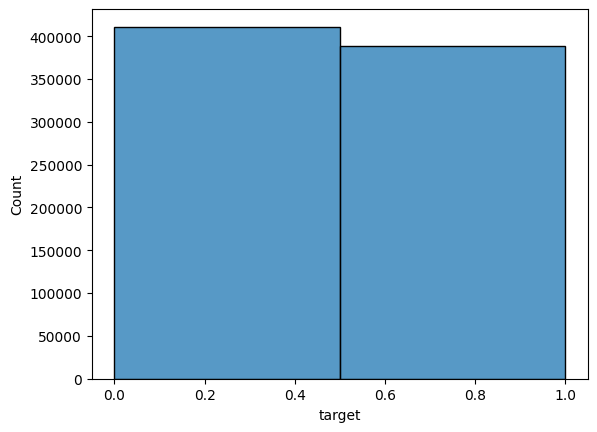

In [9]:
# NOTE: seaborn.distplot is deprecated; keep behavior with histplot for compatibility.
sns.histplot(train["target"], bins=2, kde=False)



In [10]:
target = train["target"]
target



0         1
1         0
2         0
3         1
4         1
         ..
799995    0
799996    0
799997    0
799998    0
799999    1
Name: target, Length: 800000, dtype: int64

In [11]:
# BUGFIX: DataFrame.append removed in pandas 2.x; use pd.concat.
# Keep core logic: combine train (without target) and test, then drop id and f_27.
combi = pd.concat([train.drop(["target"], axis=1), test], axis=0, ignore_index=True)
combi = combi.drop(["id", "f_27"], axis=1)
combi



,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,f_09,...,f_20,f_21,f_22,f_23,f_24,f_25,f_26,f_28,f_29,f_30
0,-0.249088,0.530642,0.335227,0.806819,-0.184190,-0.560442,1.253767,2,1,1,...,0.736091,3.929629,-1.100706,-0.078688,2.160728,0.002502,-0.827445,158.820720,0,1
1,-0.312833,0.033082,-0.571193,1.311494,0.991718,-0.138249,1.834627,2,1,2,...,-6.621721,2.618636,1.089416,-2.701227,-1.846792,9.539707,2.443596,211.389880,0,0
2,-0.370032,1.501016,0.288983,0.077866,-0.329701,0.030314,0.384582,1,3,1,...,-1.925156,-4.053491,0.313065,0.293554,-3.490299,2.002782,0.593525,81.745258,1,0
3,-1.011059,-0.341850,1.415175,-2.128660,1.137287,-3.200017,0.289945,7,2,2,...,0.295569,-1.792767,-0.626560,0.989921,-0.760995,-3.276785,-2.534943,-644.638548,0,0
4,0.756528,0.503700,0.935057,-2.321849,-0.002466,0.058981,-0.163493,1,0,2,...,2.618615,-0.877557,-1.504338,0.632537,1.812423,2.883524,-1.089711,-140.205455,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899995,0.503418,-1.153300,-0.889425,-1.179513,-0.462061,0.214669,0.307743,1,3,3,...,1.422444,-0.014319,-1.165309,-0.846506,-2.378787,1.427360,2.826281,76.703552,0,0
899996,-0.902133,-0.627760,0.162088,-1.615119,0.879754,0.987410,0.825034,0,2,0,...,0.063429,0.724684,0.317879,-1.793405,-0.431504,-5.388516,0.566487,-157.343660,1,0
899997,-1.832058,1.262797,-0.624058,-0.527734,0.197212,-0.253486,1.778342,1,2,2,...,-1.364186,-5.757202,-1.618524,-3.945195,1.268688,-2.000294,-3.963489,38.082804,0,0
899998,0.046550,-1.341361,-0.785497,-0.997895,-0.603070,-0.325951,0.479813,4,2,4,...,-2.212825,1.010819,-2.338393,-0.620072,2.750694,-1.080191,5.363695,-366.456080,0,0


<Axes: >

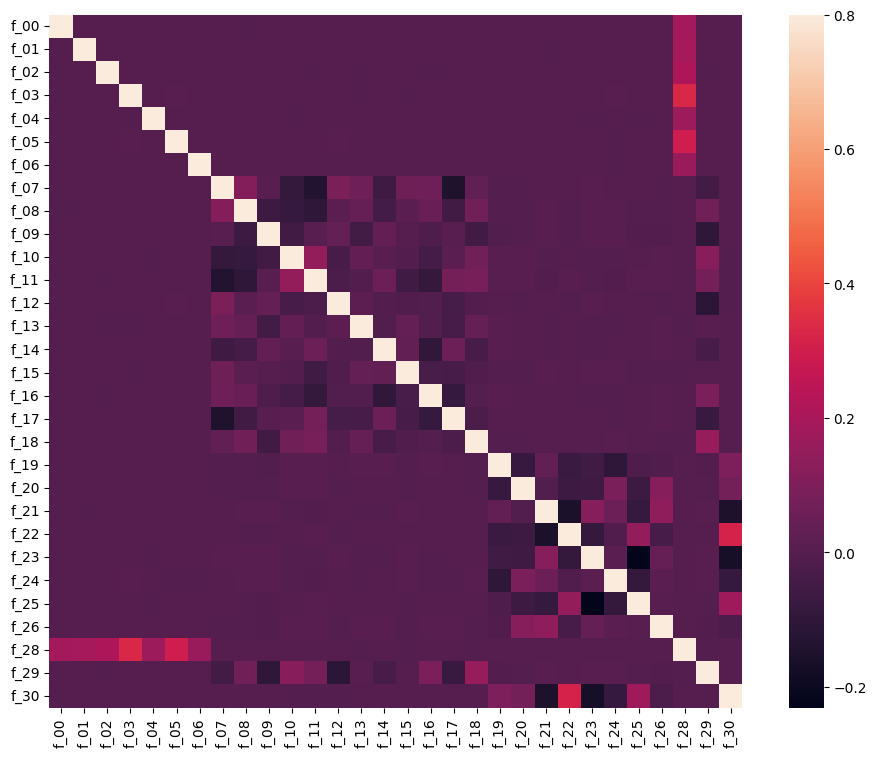

In [12]:
corr = combi.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, vmax=0.8, square=True)



In [13]:
print(corr)



          f_00      f_01      f_02      f_03      f_04      f_05      f_06  \
f_00  1.000000 -0.000303  0.001899 -0.000841 -0.000544  0.000305 -0.001312   
f_01 -0.000303  1.000000  0.000501 -0.000833 -0.000832  0.000636 -0.000441   
f_02  0.001899  0.000501  1.000000  0.000792  0.000067 -0.001109  0.000894   
f_03 -0.000841 -0.000833  0.000792  1.000000  0.001049  0.002768 -0.001092   
f_04 -0.000544 -0.000832  0.000067  0.001049  1.000000  0.000194 -0.000312   
f_05  0.000305  0.000636 -0.001109  0.002768  0.000194  1.000000  0.000233   
f_06 -0.001312 -0.000441  0.000894 -0.001092 -0.000312  0.000233  1.000000   
f_07  0.000831 -0.001220  0.001206  0.001114  0.001227  0.000407 -0.000878   
f_08 -0.002553 -0.000292  0.000339 -0.000124 -0.000251 -0.000421 -0.000635   
f_09  0.000078 -0.000566  0.001718  0.000484  0.002478 -0.000335 -0.000908   
f_10  0.000627  0.001240  0.001146 -0.000240 -0.003559 -0.000715 -0.000312   
f_11  0.001131  0.001565 -0.001822  0.002122  0.000270 -0.001091

In [14]:
columns = np.full((corr.shape[0],), True, dtype=bool)
for i in range(corr.shape[0]):
    for j in range(i + 1, corr.shape[0]):
        if corr.iloc[i, j] >= 0.80:
            if columns[j]:
                columns[j] = False
selected_columns = combi.columns[columns]
combi = combi[selected_columns]
combi



,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,f_09,...,f_20,f_21,f_22,f_23,f_24,f_25,f_26,f_28,f_29,f_30
0,-0.249088,0.530642,0.335227,0.806819,-0.184190,-0.560442,1.253767,2,1,1,...,0.736091,3.929629,-1.100706,-0.078688,2.160728,0.002502,-0.827445,158.820720,0,1
1,-0.312833,0.033082,-0.571193,1.311494,0.991718,-0.138249,1.834627,2,1,2,...,-6.621721,2.618636,1.089416,-2.701227,-1.846792,9.539707,2.443596,211.389880,0,0
2,-0.370032,1.501016,0.288983,0.077866,-0.329701,0.030314,0.384582,1,3,1,...,-1.925156,-4.053491,0.313065,0.293554,-3.490299,2.002782,0.593525,81.745258,1,0
3,-1.011059,-0.341850,1.415175,-2.128660,1.137287,-3.200017,0.289945,7,2,2,...,0.295569,-1.792767,-0.626560,0.989921,-0.760995,-3.276785,-2.534943,-644.638548,0,0
4,0.756528,0.503700,0.935057,-2.321849,-0.002466,0.058981,-0.163493,1,0,2,...,2.618615,-0.877557,-1.504338,0.632537,1.812423,2.883524,-1.089711,-140.205455,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899995,0.503418,-1.153300,-0.889425,-1.179513,-0.462061,0.214669,0.307743,1,3,3,...,1.422444,-0.014319,-1.165309,-0.846506,-2.378787,1.427360,2.826281,76.703552,0,0
899996,-0.902133,-0.627760,0.162088,-1.615119,0.879754,0.987410,0.825034,0,2,0,...,0.063429,0.724684,0.317879,-1.793405,-0.431504,-5.388516,0.566487,-157.343660,1,0
899997,-1.832058,1.262797,-0.624058,-0.527734,0.197212,-0.253486,1.778342,1,2,2,...,-1.364186,-5.757202,-1.618524,-3.945195,1.268688,-2.000294,-3.963489,38.082804,0,0
899998,0.046550,-1.341361,-0.785497,-0.997895,-0.603070,-0.325951,0.479813,4,2,4,...,-2.212825,1.010819,-2.338393,-0.620072,2.750694,-1.080191,5.363695,-366.456080,0,0


In [15]:
# Keep original min-max scaling approach; add safe denominator to avoid division by zero.
den = (combi.max() - combi.min()).replace(0, 1.0)
combi = (combi - combi.min()) / den
combi



,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,f_09,...,f_20,f_21,f_22,f_23,f_24,f_25,f_26,f_28,f_29,f_30
0,0.465365,0.548841,0.518280,0.599714,0.470670,0.430954,0.630762,0.133333,0.0625,0.071429,...,0.527598,0.620905,0.463532,0.497894,0.570314,0.487609,0.495088,0.564618,0.0,0.5
1,0.458547,0.496455,0.423907,0.655089,0.591929,0.474380,0.690858,0.133333,0.0625,0.142857,...,0.203939,0.573688,0.557943,0.391062,0.401974,0.877719,0.615287,0.585993,0.0,0.0
2,0.452428,0.651009,0.513465,0.519730,0.455665,0.491718,0.540836,0.066667,0.1875,0.071429,...,0.410534,0.333386,0.524476,0.513058,0.332936,0.569428,0.547303,0.533278,1.0,0.0
3,0.383863,0.456980,0.630720,0.277620,0.606940,0.159451,0.531045,0.466667,0.1250,0.142857,...,0.508220,0.414808,0.483971,0.541425,0.447584,0.353473,0.432344,0.237918,0.0,0.0
4,0.572927,0.546005,0.580732,0.256423,0.489409,0.494667,0.484133,0.066667,0.0000,0.142857,...,0.610407,0.447770,0.446132,0.526867,0.555683,0.605454,0.485451,0.443029,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899995,0.545854,0.371545,0.390774,0.381765,0.442016,0.510680,0.532887,0.066667,0.1875,0.214286,...,0.557789,0.478860,0.460747,0.466616,0.379627,0.545891,0.629349,0.531228,0.0,0.0
899996,0.395514,0.426877,0.500254,0.333968,0.580383,0.590163,0.586405,0.000000,0.1250,0.000000,...,0.498008,0.505476,0.524684,0.428043,0.461424,0.267095,0.546310,0.436060,1.0,0.0
899997,0.296048,0.625928,0.418403,0.453281,0.510000,0.462527,0.685035,0.066667,0.1250,0.142857,...,0.435210,0.272026,0.441210,0.340388,0.532843,0.405686,0.379850,0.515524,0.0,0.0
899998,0.496987,0.351745,0.401595,0.401693,0.427475,0.455073,0.550689,0.266667,0.1250,0.285714,...,0.397880,0.515781,0.410177,0.475840,0.595096,0.443322,0.722589,0.351031,0.0,0.0


In [16]:
y = target
X = combi.iloc[: len(train)].copy()
X_test = combi.iloc[len(train) :].copy()



In [17]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X_train.shape, X_val.shape, y_train.shape, y_val.shape, X_test.shape



((720000, 30), (80000, 30), (720000,), (80000,), (100000, 30))

In [18]:
from sklearn.linear_model import LogisticRegression

# Keep LogisticRegression core model; set max_iter to ensure convergence on this dataset size.
model = LogisticRegression(random_state=42, max_iter=1000, n_jobs=1).fit(
    X_train, y_train
)
print(model.score(X_train, y_train))



0.6147166666666667


In [19]:
# For ROC AUC, probabilities are needed (not hard labels).
from sklearn.metrics import roc_auc_score

val_proba = model.predict_proba(X_val)[:, 1]
print("Validation ROC AUC:", roc_auc_score(y_val, val_proba))



Validation ROC AUC: 0.6594277760579036


In [20]:
from sklearn.metrics import confusion_matrix

y_pred = (val_proba >= 0.5).astype(int)
print(confusion_matrix(y_val, y_pred))



[[26884 14225]
 [16538 22353]]


In [21]:
# IMPORTANT: submission requires probability, not class label.
preds = model.predict_proba(X_test)[:, 1].astype(float)
preds = np.clip(preds, 0.0, 1.0)
preds[:10], preds.min(), preds.max()



(array([0.42698898, 0.60555377, 0.57708264, 0.38471188, 0.37376632,
        0.51563969, 0.39946152, 0.4007726 , 0.35344368, 0.4264407 ]),
 0.0674230956666704,
 0.942236887252841)

In [22]:
# Ensure id alignment and correct submission format.
out = pd.DataFrame({"id": test["id"].values, "target": preds})
out.to_csv("submission.csv", index=False)

# quick sanity check
sub_check = pd.read_csv("submission.csv")
sub_check.head(), sub_check.shape

(       id    target
 0  800000  0.426989
 1  800001  0.605554
 2  800002  0.577083
 3  800003  0.384712
 4  800004  0.373766,
 (100000, 2))